# Tweets Sentiment Analysis Project

## Introduction
Social media platforms, particularly Twitter, have become powerful channels for public expression, discussion, and opinion sharing. Millions of tweets are generated daily, covering diverse topics such as politics, entertainment, business, and personal experiences. These tweets often contain valuable insights into public sentiment, making Twitter a rich source of data for sentiment analysis. By leveraging Natural Language Processing (NLP) techniques, sentiment analysis enables us to classify tweets into categories such as positive, negative, or neutral, providing actionable intelligence for businesses, policymakers, and researchers.

## Problem Statement
Despite the abundance of data on Twitter, extracting meaningful sentiment information poses significant challenges. Tweets are often short, informal, and filled with slang, abbreviations, emojis, and hashtags, which complicates text processing. Traditional sentiment analysis models struggle to capture the nuances of human expression in such contexts. The problem this project aims to address is: **How can we design and implement an effective sentiment analysis system that accurately classifies tweets into sentiment categories, while handling the complexities of informal language and contextual meaning?**

This project seeks to build a robust sentiment analysis pipeline that preprocesses raw tweets, applies machine learning or deep learning models, and evaluates performance to ensure reliable sentiment classification. The ultimate goal is to provide insights into public opinion trends and support decision-making in areas such as marketing, politics, and social research.

## 2. Data Loading & Inspection


In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.naive_bayes import MultinomialNB


In [2]:
df = pd.read_csv("../data/tweets.csv")

In [3]:
df.describe()

,textID,text,selected_text,sentiment
count,27481,27480,27480,27481
unique,27481,27480,22463,3
top,cb774db0d1,"I`d have responded, if I were going",good,neutral
freq,1,1,199,11118


In [4]:
df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [5]:
df.shape

(27481, 4)

In [6]:
df['sentiment'].unique()

array(['neutral', 'negative', 'positive'], dtype=object)

In [7]:
#check for missing values
print(df.isnull().sum())

textID           0
text             1
selected_text    1
sentiment        0
dtype: int64


In [8]:
#drop missing values
df.dropna(inplace= True)
df.count()

textID           27480
text             27480
selected_text    27480
sentiment        27480
dtype: int64

In [9]:
#check duplicates
df.duplicated().sum()

0

In [10]:
# Drop Unnecessary column
df.drop(columns=['textID', 'selected_text'], inplace=True)
df.head()

,text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative


In [12]:
#Number of stop Words:
nltk.download('stopwords')
stop = stopwords.words('english')

df['stopwords'] = df['text'].apply(lambda x: len([x for x in x.split() if x in stop]))
df[['text','stopwords']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,text,stopwords
0,"I`d have responded, if I were going",3
1,Sooo SAD I will miss you here in San Diego!!!,4
2,my boss is bullying me...,2
3,what interview! leave me alone,2
4,"Sons of ****, why couldn`t they put them on t...",7


## 3. Data Cleaning & Preprocessing

Twitter data is highly unstructured and noisy. Tweets often contain URLs, emojis, special characters, inconsistent capitalization, and irregular spacing.
If left unprocessed, this noise can negatively affect model performance by introducing irrelevant or misleading features.

To address this, a text cleaning pipeline was applied to standardize the input text while preserving meaningful information.
Stemming and lemmatization were not applied in the baseline model to preserve original word forms and sentiment intensity. These techniques may be explored in future iterations as part of model optimization.

In [13]:
#Removal of StopWords
df['text'] = df['text'].apply(lambda x: " ".join(x for x in x.split() if x not in stop))
df['text'].head()

0                             I`d responded, I going
1                       Sooo SAD I miss San Diego!!!
2                                boss bullying me...
3                             interview! leave alone
4    Sons ****, couldn`t put releases already bought
Name: text, dtype: object

In [14]:
freq = pd.Series(' '.join(df['text']).split()).value_counts()[:30]
freq

I         8802
I`m       1696
get       1373
like      1258
day       1165
-         1147
go        1101
good      1032
got        961
going      911
love       880
work       837
****       796
one        775
really     773
it`s       767
u          761
don`t      759
know       744
see        729
back       697
&          675
time       672
want       660
new        654
im         632
think      631
can`t      622
2          613
still      577
Name: count, dtype: int64

In [15]:
freq =["I'm","im", "-", "****", "&"]
df['text']= df['text'].apply(lambda x: " ".join(x for x in x.split() if x not in freq))
df['text'].head()

0                             I`d responded, I going
1                       Sooo SAD I miss San Diego!!!
2                                boss bullying me...
3                             interview! leave alone
4    Sons ****, couldn`t put releases already bought
Name: text, dtype: object

In [16]:
#clean the dataset
def cleaning_text(text): 
    text = text.lower() 
    text = re.sub(r"http\S+|www\S+", "", text) 
    text = re.sub(r"[^a-z\s]", "", text) 
    text = re.sub(r"\s+", " ", text).strip() 
    return text 
    
df['clean_text'] = df['text'].apply(cleaning_text)
df['clean_text']

0                                     id responded i going
1                                sooo sad i miss san diego
2                                         boss bullying me
3                                    interview leave alone
4                 sons couldnt put releases already bought
                               ...                        
27476    wish could come see u denver husband lost job ...
27477    ive wondered rake to the client made clear net...
27478    yay good you enjoy break probably need hectic ...
27479                                            but worth
27480           all flirting going the atg smiles yay hugs
Name: clean_text, Length: 27480, dtype: object

In [17]:
le = LabelEncoder()
y_encoded = le.fit_transform(df['sentiment'])

X = df['clean_text']

In [18]:
X = df['clean_text']
y = y_encoded

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Feature Engineering with TF-IDF
### Why TF-IDF was chosen

Term Frequency–Inverse Document Frequency (TF-IDF) was selected as the primary feature representation technique because it effectively balances:

    Term frequency (how often a word appears in a tweet)

    Inverse document frequency (how informative a word is across all tweets)
This helps reduce the impact of commonly used but less informative words while emphasizing sentiment-bearing terms.

*N-gram range selection*

Unigrams and bigrams were used:
Unigrams capture individual sentiment words (e.g., “good”, “bad”),
while bigrams capture short contextual phrases (e.g., “not good”, “very bad”) that improve sentiment understanding.

In [20]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


## EDA

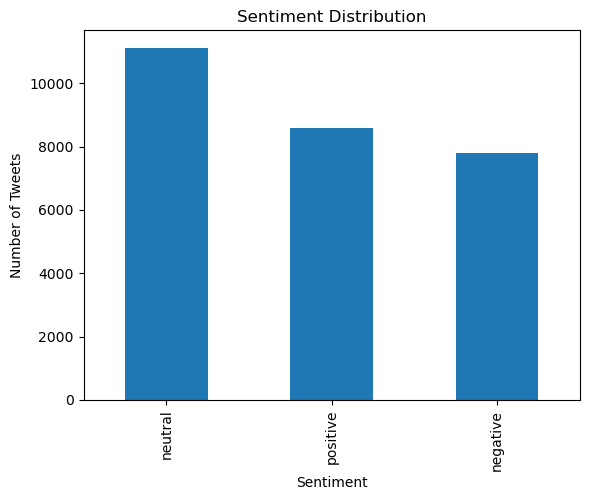

In [21]:
sentiment_counts = df['sentiment'].value_counts()

sentiment_counts.plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.show()


In [22]:
def get_top_words(sentiment, n=10):
    text = " ".join(df[df['sentiment'] == sentiment]['clean_text'])
    words = text.split()
    return Counter(words).most_common(n)
    
get_top_words('positive')

[('i', 2519),
 ('day', 1234),
 ('good', 1046),
 ('love', 875),
 ('happy', 840),
 ('mothers', 629),
 ('im', 603),
 ('thanks', 554),
 ('you', 484),
 ('great', 478)]

In [23]:
get_top_words('negative')


[('i', 2991),
 ('im', 972),
 ('like', 476),
 ('dont', 469),
 ('cant', 466),
 ('get', 436),
 ('miss', 422),
 ('its', 417),
 ('go', 401),
 ('sad', 389)]

In [24]:
get_top_words('neutral')

[('i', 3406),
 ('im', 848),
 ('get', 624),
 ('go', 576),
 ('its', 523),
 ('day', 522),
 ('dont', 493),
 ('going', 479),
 ('work', 477),
 ('like', 457)]

## TRAIN AND MODEL

In [25]:
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

log_reg.fit(X_train_tfidf, y_train)

y_pred_lr = log_reg.predict(X_test_tfidf)

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))


Logistic Regression Classification Report:
              precision    recall  f1-score   support

    negative       0.66      0.69      0.67      1556
     neutral       0.65      0.65      0.65      2223
    positive       0.75      0.72      0.74      1717

    accuracy                           0.68      5496
   macro avg       0.69      0.69      0.69      5496
weighted avg       0.69      0.68      0.68      5496



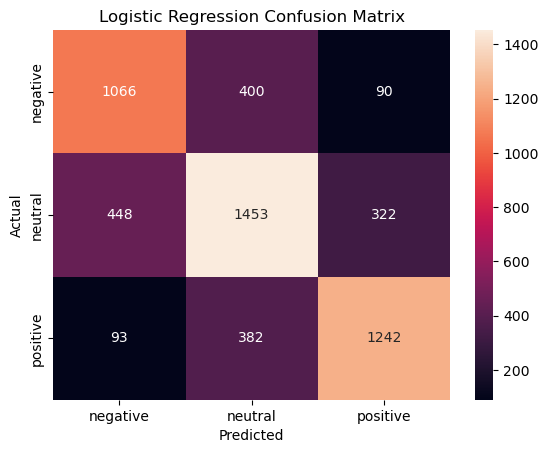

In [26]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm_lr, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [27]:
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
y_pred_nb = nb.predict(X_test_tfidf)

print("Naive Bayes Classification Report:")
print(classification_report(y_test, y_pred_nb, target_names=le.classes_))


Naive Bayes Classification Report:
              precision    recall  f1-score   support

    negative       0.73      0.51      0.60      1556
     neutral       0.56      0.78      0.65      2223
    positive       0.77      0.59      0.67      1717

    accuracy                           0.64      5496
   macro avg       0.69      0.63      0.64      5496
weighted avg       0.67      0.64      0.64      5496



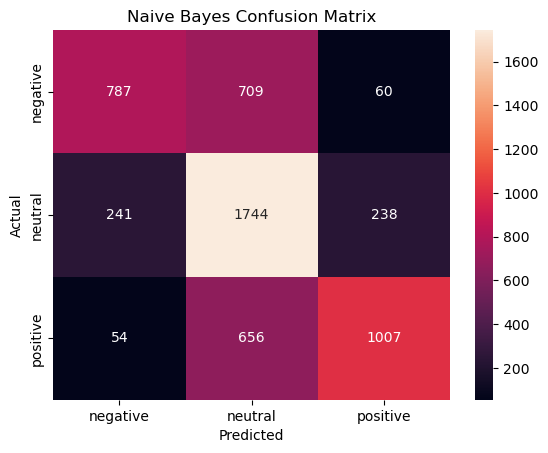

In [28]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

sns.heatmap(cm_nb, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Error Analysis
Many misclassifications occur in tweets containing mixed sentiment or sarcasm.

In [29]:
results = pd.DataFrame({
    'tweet': X_test,
    'true_label': le.inverse_transform(y_test),
    'pred_label': le.inverse_transform(y_pred_lr)
})

misclassified = results[results['true_label'] != results['pred_label']]
misclassified.head(30)


,tweet,true_label,pred_label
4127,hoping heal its anything i put makes worse owww,neutral,negative
20627,im sooo lovei think,positive,neutral
13239,get fired hugs,neutral,positive
4832,yum do home delivery,positive,neutral
10652,shack idol today cant wait its gonna funnn poo...,neutral,negative
17484,a hugs i wish i could help,negative,positive
5693,dont know guys radio disney much energy wouldn...,neutral,negative
3704,frat thats bad should good show at least im ho...,neutral,positive
6263,pm ok lets go bowman strategicclock first brea...,negative,neutral
3867,and its starting get cold,neutral,negative


In [30]:
def error_type(row):
    text = row['tweet']
    true = row['true_label']
    pred = row['pred_label']
    
    if 'not' in text or "n't" in text:
        return 'negation'
    elif len(text.split()) <= 3:
        return 'very short tweet'
    elif true == 'neutral':
        return 'ambiguous / neutral'
    else:
        return 'other'

misclassified['error_category'] = misclassified.apply(error_type, axis=1)
misclassified['error_category'].value_counts()


C:\Users\user\AppData\Local\Temp\ipykernel_18524\3383736280.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  misclassified['error_category'] = misclassified.apply(error_type, axis=1)


error_category
other                  842
ambiguous / neutral    651
very short tweet       170
negation                72
Name: count, dtype: int64